In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dipakbharate","key":"ee1b2d94d8d7967b8b68f71d57192629"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:13<00:00, 249MB/s]
100% 2.04G/2.04G [00:13<00:00, 167MB/s]


In [ ]:
!unzip -q plantvillage-dataset.zip "plantvillage dataset/color/*" -d ./data/PlantVillage


##Preprocessing

In [ ]:
# 2️⃣ Import Libraries
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 3️⃣ Define Paths
PROJECT_ROOT = Path("/content")
DATA_DIR = PROJECT_ROOT / "data" / "PlantVillage" / "plantvillage dataset" / "color"
MODEL_SAVE_PATH = PROJECT_ROOT / "smartfarm_cnn_best_model.keras"

print(f"✅ Dataset Path: {DATA_DIR}")
print(f"✅ Model Save Path: {MODEL_SAVE_PATH}")


✅ Dataset Path: /content/data/PlantVillage/plantvillage dataset/color
✅ Model Save Path: /content/smartfarm_cnn_best_model.keras


In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

print(f"✅ Classes found: {train_gen.num_classes}")

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
✅ Classes found: 38


In [ ]:
# 5️⃣ CNN Model Definition

model = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 6️⃣ Model Training

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

# Save best model
model.save(MODEL_SAVE_PATH)
print(f"✅ Model saved to: {MODEL_SAVE_PATH}")


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 66s 44ms/step - accuracy: 0.4416 - loss: 2.0682 - val_accuracy: 0.8149 - val_loss: 0.5892
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 55s 41ms/step - accuracy: 0.7890 - loss: 0.6866 - val_accuracy: 0.8797 - val_loss: 0.3856
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 57s 42ms/step - accuracy: 0.8516 - loss: 0.4597 - val_accuracy: 0.9024 - val_loss: 0.3028
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 55s 41ms/step - accuracy: 0.8861 - loss: 0.3446 - val_accuracy: 0.9080 - val_loss: 0.2764
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 57s 42ms/step - accuracy: 0.9042 - loss: 0.2867 - val_accuracy: 0.9227 - val_loss: 0.2381
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 58s 43ms/step - accuracy: 0.9239 - loss: 0.2255 - val_accuracy: 0.9291 - val_loss: 0.2333
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 56s 41ms/step - accuracy: 0.9294 - loss: 0.2122 - val_accuracy: 0.9257 - val_loss: 0.2436
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 56s 41ms/step - accuracy: 0.9417 - loss: 0.17

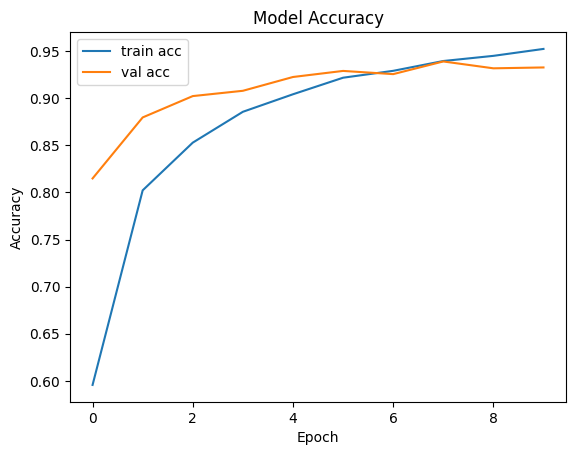

In [ ]:
# 7️⃣ Training Visualization

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
import json

class_indices = train_gen.class_indices
with open("/content/class_indices.json", "w") as f:
    json.dump(class_indices, f)

print("✅ Class indices saved!")


✅ Class indices saved!


In [ ]:
from tensorflow.keras.models import load_model

# Path where your model was saved
model_path = "/content/smartfarm_cnn_best_model.keras"

# Load the model
model = load_model(model_path)

print("✅ Model loaded successfully!")
model.summary()


✅ Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,928,628 (37.87 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,619,086 (25.25 MB)

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Path to your test image
img_path = "/content/data/PlantVillage/plantvillage dataset/color/Tomato___healthy/000146ff-92a4-4db6-90ad-8fce2ae4fddd___GH_HL Leaf 259.1.JPG"

# Load and preprocess the image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Make prediction
pred = model.predict(img_array)
predicted_class = np.argmax(pred, axis=1)

print("Predicted class index:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class index: [37]


In [ ]:
import os

# Path to your dataset folders
data_dir = "/content/data/PlantVillage/plantvillage dataset/color"
class_names = sorted(os.listdir(data_dir))

print("Total classes:", len(class_names))
print("Example:", class_names[:5])  # show first 5


Total classes: 38
Example: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [ ]:
print("Predicted disease:", class_names[predicted_class[0]])

Predicted disease: Tomato___healthy


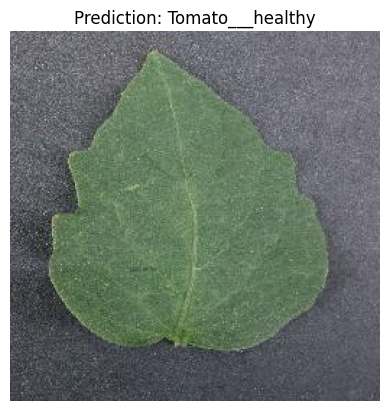

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image.load_img(img_path))
plt.title(f"Prediction: {class_names[predicted_class[0]]}")
plt.axis("off")
plt.show()
